# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [8]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_held,0.058
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_held,H,glycine_held,e,2598.06,0.0393 
propanol,H,glycine_held,e,2437.43,0.023492
propanol,e,glycine_held,H,2437.43,0.023492
"""
components = ["propanol", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[233.4 211.97818276628374; 211.97818276628374 216.96]
[3.2522000000000004e-10 2.7896000000000004e-10; 2.7896000000000004e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2276.8, 2437.43, 2437.43, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.015268, 0.023492, 0.023492, 0.0393]
kij = 0.05800000000000005
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          0.000308046
   2 │      288.512        0.000630142
   3 │      307.025        0.00117975
   4 │      325.538        0.00205639
   5 │      344.05         0.00338239
   6 │      362.562        0.00530632
   7 │      381.075        0.00800828
   8 │      399.587        0.0117072
   9 │      418.1          0.0166692
  10 │      436.612        0.0232152
  11 │      455.125        0.0317212
  12 │      473.638        0.0425906
  13 │      492.15         0.0561303
  14 │      510.662        0.071949
  15 │      529.175      NaN
  16 │      547.688        0.15634
  17 │      566.2          0.26241
  18 │      584.712        0.542573
  19 │      603.225        0.57245
  20 │      621.737        0.672637
  21 │      640.25         0.825881
  22 │      658.762        0.0
  23 │      677.275      NaN
  24

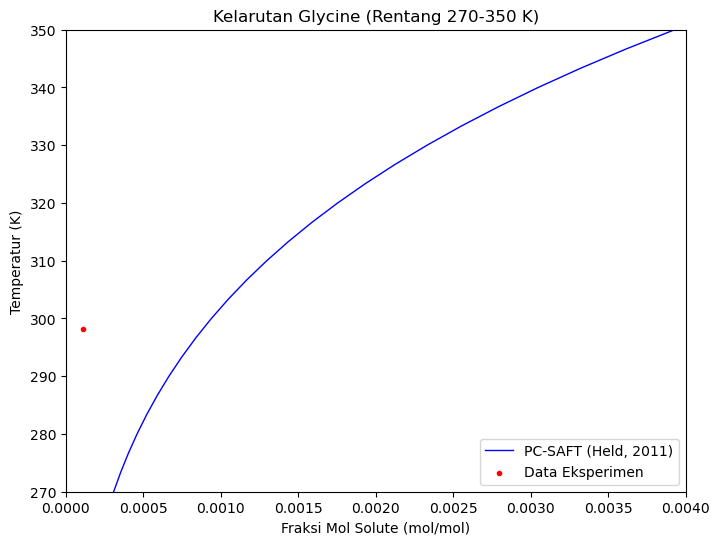

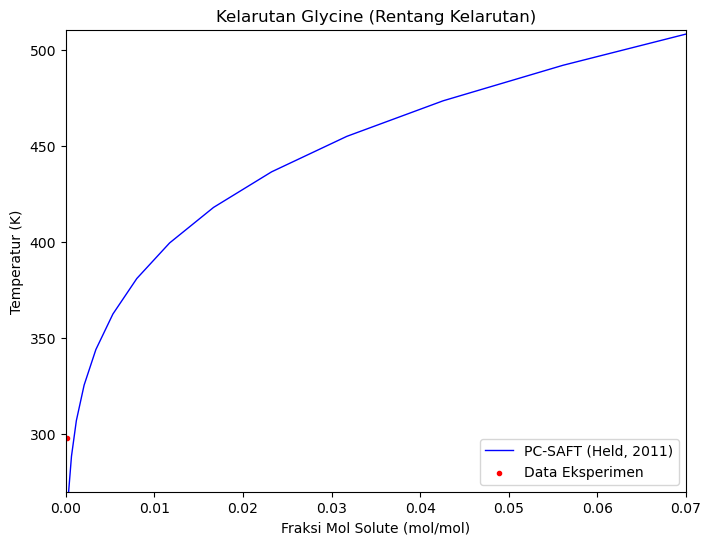

In [9]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.004)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270.,model1.solid.params.Tm[2], 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.07)
    plt.ylim(270.0, 510.662)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [6]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [10]:
aard_p   = calculate_AAD(model1, "sol_glycine_propanol.csv", solubility_held)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000882      688.2677
AARD = 688.2677%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


688.2676889044318

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [11]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.055028
propanol,glycine_gcmid,0.055028
propanol,glycine_gcup,0.055028
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
"""
components_low = ["propanol", "glycine_gclow"]
components_mid = ["propanol", "glycine_gcmid"]
components_up = ["propanol", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000230481  5.71585e-5   1.28405e-5
   2 │      276.498  0.000325398  8.46921e-5   1.99739e-5
   3 │      282.997  0.00045081   0.00012285   3.03471e-5
   4 │      289.495  0.000613669  0.0001747    4.51052e-5
   5 │      295.993  0.000821787  0.000243874  6.56761e-5
   6 │      302.492  0.0010838    0.000334589  9.38056e-5
   7 │      308.99   0.00140911   0.000451661  0.000131587
   8 │      315.489  0.00180788   0.000600499  0.000181483
   9 │      321.987  0.00229091   0.000787086  0.000246344
  10 │      328.485  0.00286963   0.00101795   0.000329416
  11 │      334.984  0.00355607   0.00130013   0.000434331
  12 │      341.482  0.00436284   0.0016411    0.000565104
  13 │      347.981  0.00530319   0.00204878   0.000726101
  14 │     

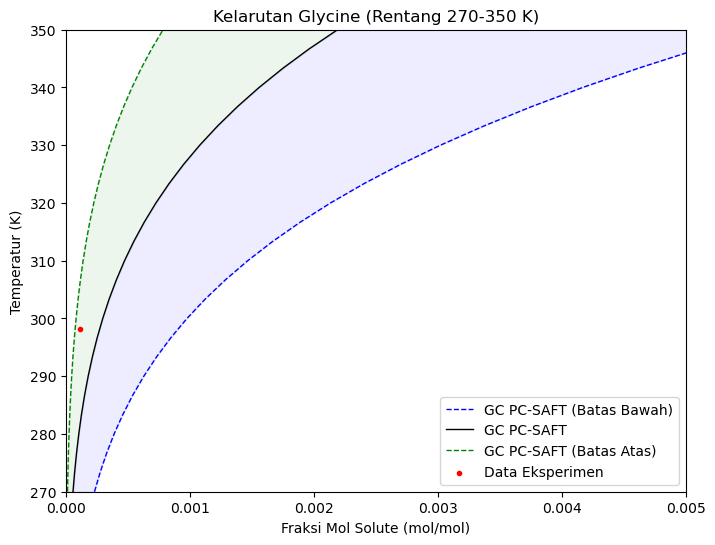

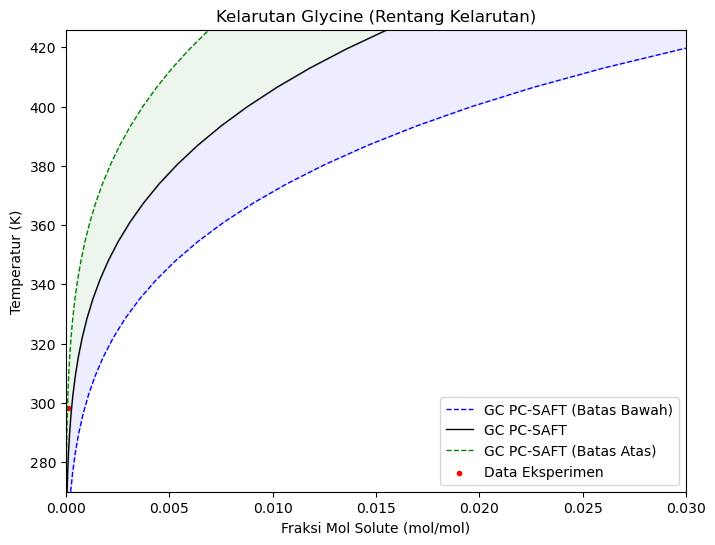

In [14]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.005)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.03)
    plt.ylim(270.0, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [15]:
aard_p   = calculate_AAD(model2_low, "sol_glycine_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000902      706.3420
AARD = 706.3420%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


706.341954056771

In [16]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000271      142.5021
AARD = 142.5021%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


142.50214453691657

In [17]:
aard_p   = calculate_AAD(model2_up, "sol_glycine_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


298.1500    0.000112      0.000074      33.8016 
AARD = 33.8016%


33.80155712582069

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [18]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_held,0.055028
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_held,H,glycine_held,e,3012.118,0.267058
propanol,H,glycine_held,e,2644.459,0.060431
propanol,e,glycine_held,H,2644.459,0.060431
"""
components = ["propanol", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[233.4 223.00382975946988; 223.00382975946988 238.6085]
[3.2522000000000004e-10 2.7331e-10; 2.7331e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2276.8, 2644.459, 2644.459, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.015268, 0.060431, 0.060431, 0.267058]
kij = 0.055027999999999966
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          8.58438e-5
   2 │      279.583        0.000128892
   3 │      289.167        0.00018709
   4 │      298.75         0.000263371
   5 │      308.333        0.000360567
   6 │      317.917        0.000481251
   7 │      327.5          0.000627576
   8 │      337.083        0.000801133
   9 │      346.667        0.00100283
  10 │      356.25         0.00123283
  11 │      365.833        0.00149043
  12 │      375.417        0.00177412
  13 │      385.0          0.00208154
  14 │      394.583        0.00240948
  15 │      404.167        0.00275395
  16 │      413.75         0.00311015
  17 │      423.333        0.00347245
  18 │      432.917        0.00383433
  19 │      442.5          0.00418814
  20 │      452.083        0.00452477
  21 │      461.667        0.00483292
  22 │      471.25         0

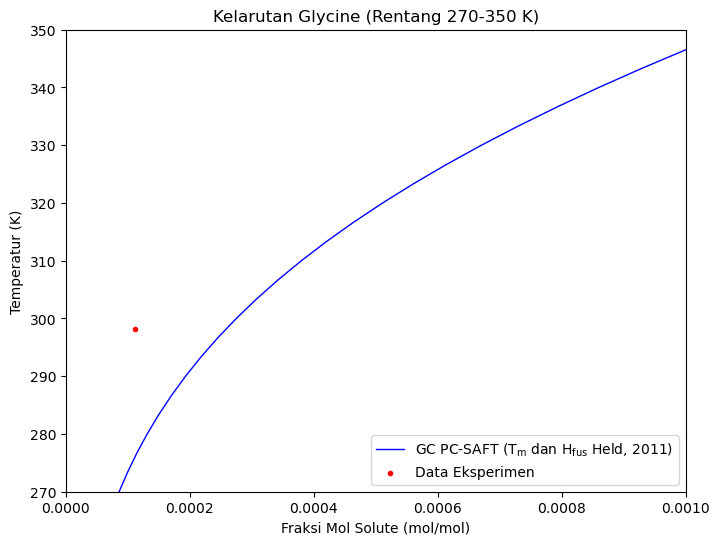

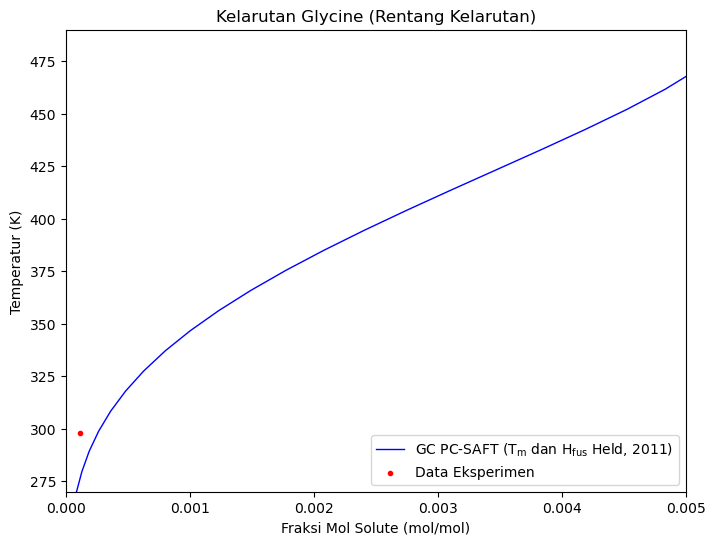

In [20]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.001)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., 500., 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.005)
    plt.ylim(270.0, 490.)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [21]:
aard_p   = calculate_AAD(model3, "sol_glycine_propanol.csv", solubility_held)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000258      130.5673
AARD = 130.5673%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


130.56730333148727

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [22]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.053
propanol,glycine_gcmid,0.053
propanol,glycine_gcup,0.053
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
"""
components_low = ["propanol", "glycine_gclow"]
components_mid = ["propanol", "glycine_gcmid"]
components_up = ["propanol", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000244541  6.06414e-5   1.36227e-5
   2 │      276.498  0.000344616  8.96864e-5   2.11513e-5
   3 │      282.997  0.000476605  0.000129865  3.2079e-5
   4 │      289.495  0.000647713  0.000184365  4.75985e-5
   5 │      295.993  0.000866016  0.000256952  6.91942e-5
   6 │      302.492  0.00114043   0.000351991  9.86771e-5
   7 │      308.99   0.00148066   0.000474455  0.000138214
   8 │      315.489  0.00189714   0.00062992   0.000190351
   9 │      321.987  0.00240099   0.000824544  0.000258028
  10 │      328.485  0.00300396   0.00106503   0.000344584
  11 │      334.984  0.0037184    0.0013586    0.000453756
  12 │      341.482  0.00455729   0.00171292   0.000589659
  13 │      347.981  0.00553424   0.00213608   0.000756767
  14 │      

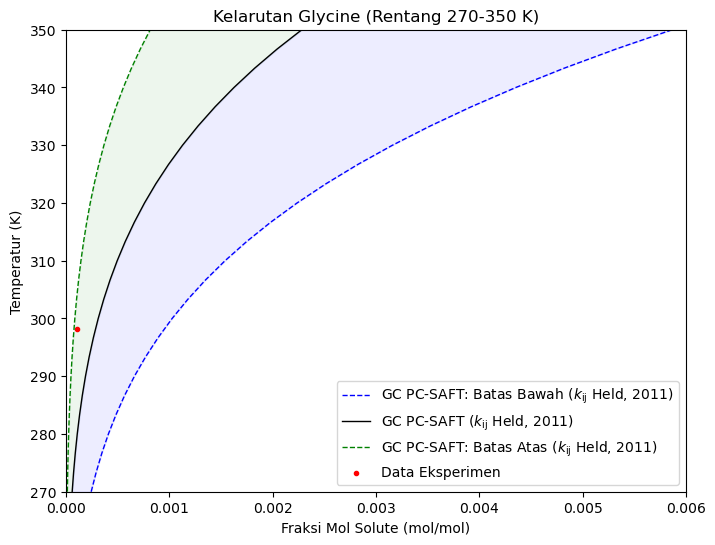

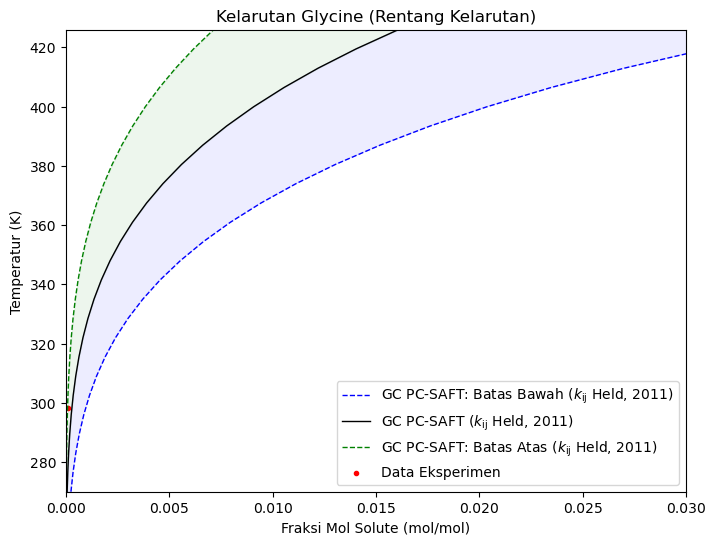

In [24]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.006)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.03)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [25]:
aard_p   = calculate_AAD(model4_low, "sol_glycine_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000950      749.3132
AARD = 749.3132%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


749.3131606489768

In [26]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000286      155.3745
AARD = 155.3745%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


155.3744967515401

In [27]:
aard_p   = calculate_AAD(model4_up, "sol_glycine_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000078      30.2920 
AARD = 30.2920%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


30.291981138631936

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [28]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0
propanol,glycine_gcmid,0
propanol,glycine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
"""
components_low = ["propanol", "glycine_gclow"]
components_mid = ["propanol", "glycine_gcmid"]
components_up = ["propanol", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid        X_Up        
     │ Float64       Float64     Float64      Float64     
─────┼────────────────────────────────────────────────────
   1 │      270.0    0.001156    0.000285634  6.41071e-5
   2 │      276.498  0.00155397  0.000402519  9.48091e-5
   3 │      282.997  0.00205538  0.000556656  0.000137271
   4 │      289.495  0.00267811  0.000756433  0.000194853
   5 │      295.993  0.00344146  0.00101123   0.000271511
   6 │      302.492  0.00436608  0.0013314    0.000371823
   7 │      308.99   0.00547405  0.00172815   0.000500986
   8 │      315.489  0.00678908  0.00221357   0.000664806
   9 │      321.987  0.00833674  0.00280049   0.000869667
  10 │      328.485  0.0101451   0.00350244   0.00112248
  11 │      334.984  0.0122453   0.00433371   0.00143064
  12 │      341.482  0.0146732   0.00530929   0.00180195
  13 │      347.981  0.0174708   0.00644507   0.00224457
  14 │      354.479  0.0206

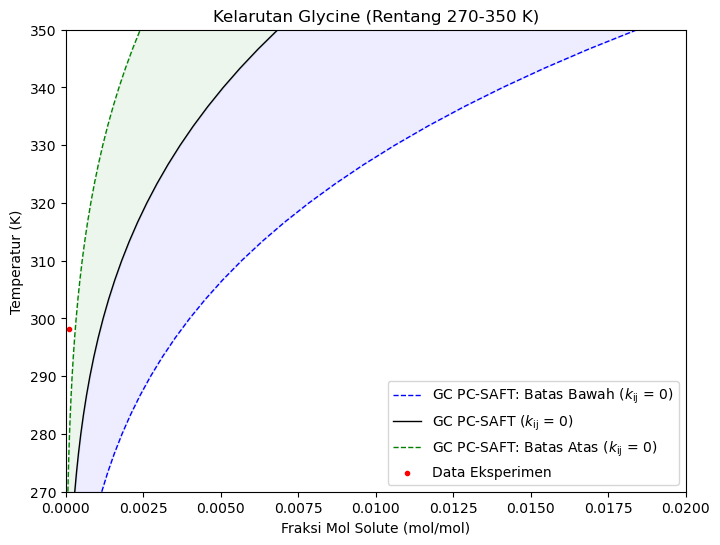

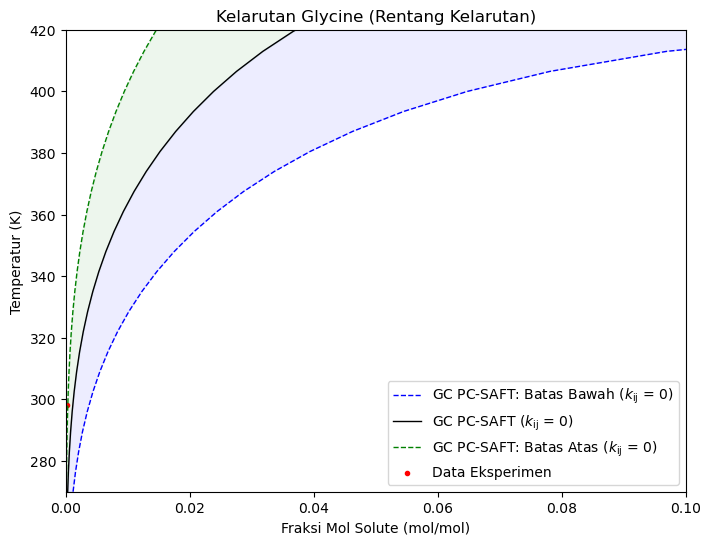

In [32]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.02)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.1)
    plt.ylim(270.0, 420.)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [33]:
aard_p   = calculate_AAD(model5_low, "sol_glycine_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.003729      3232.7033
AARD = 3232.7033%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


3232.7032596752197

In [34]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.001110      891.6696
AARD = 891.6696%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


891.6696229320676

In [35]:
aard_p   = calculate_AAD(model5_up, "sol_glycine_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000302      169.8203
AARD = 169.8203%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


169.8202682596317

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [36]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.055800569
propanol,glycine_gcmid,0.055800569
propanol,glycine_gcup,0.055800569
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
"""
components_low = ["propanol", "glycine_gclow"]
components_mid = ["propanol", "glycine_gcmid"]
components_up = ["propanol", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000225341  5.58851e-5   1.25545e-5
   2 │      276.498  0.000318363  8.28637e-5   1.95429e-5
   3 │      282.997  0.000441356  0.000120278  2.97123e-5
   4 │      289.495  0.000601179  0.000171153  4.41902e-5
   5 │      295.993  0.000805542  0.000239069  6.43836e-5
   6 │      302.492  0.00106298   0.000328189  9.2014e-5
   7 │      308.99   0.00138279   0.00044327   0.000129147
   8 │      315.489  0.00177501   0.000589658  0.000178214
   9 │      321.987  0.00225033   0.000773271  0.000242035
  10 │      328.485  0.00282008   0.00100057   0.000323815
  11 │      334.984  0.00349615   0.00127853   0.000427153
  12 │      341.482  0.00429103   0.00161455   0.000556023
  13 │      347.981  0.00521782   0.00201648   0.000714751
  14 │      

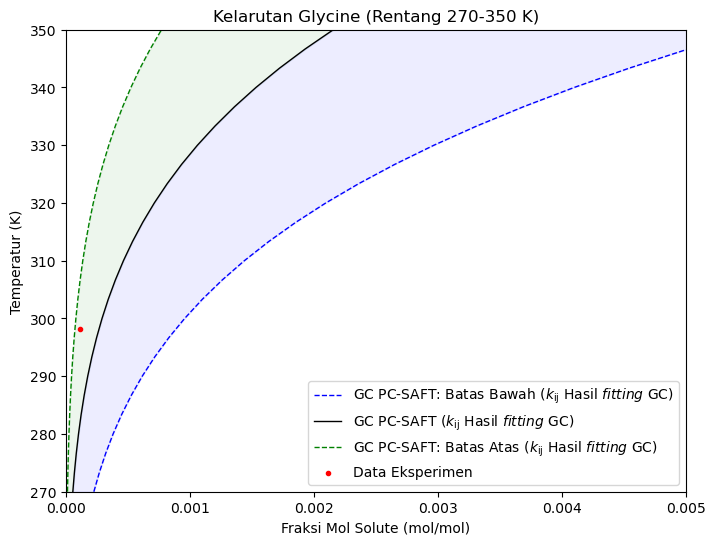

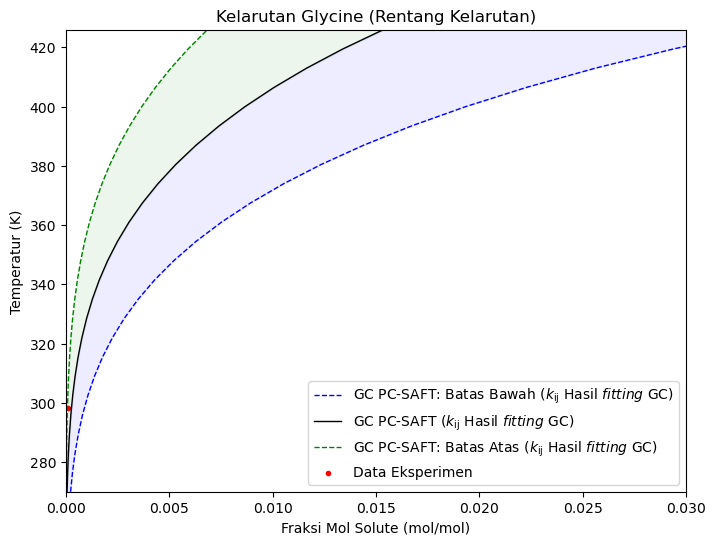

In [38]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_propanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.005)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.03)
    plt.ylim(270.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_glycine_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [39]:
aard_p   = calculate_AAD(model6_low, "sol_glycine_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000885      690.5543
AARD = 690.5543%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


690.5543446659001

In [40]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000266      137.7716
AARD = 137.7716%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


137.77162452092972

In [41]:
aard_p   = calculate_AAD(model6_up, "sol_glycine_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000112      0.000073      35.0914 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


AARD = 35.0914%


35.09141084300351